# Overview

Implementing Machine and Deep Learning Algorithms from Scratch. In this notebook, we'll be implementing Logistic Regression algorithm from scratch.

For this task we'll use the [Breast Cancer Wisconsin Dataset](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data).

# Imports

In [1]:
import pandas as pd # for Data Analysis
import numpy as np # for Linear Algebra
import matplotlib.pyplot as plt # for Visualization
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, roc_curve, auc, PrecisionRecallDisplay, RocCurveDisplay

# Load the dataset

In [2]:
data = pd.read_csv("/kaggle/input/datasets/organizations/uciml/breast-cancer-wisconsin-data/data.csv")

### Understanding the dataset

Ten real-valued features are computed for each cell nucleus:

1. radius (mean of distances from center to points on the perimeter)
2. texture (standard deviation of gray-scale values)
3. perimeter
4. area
5. smoothness (local variation in radius lengths)
6. compactness (perimeter^2 / area - 1.0)
7. concavity (severity of concave portions of the contour)
8. concave points (number of concave portions of the contour)
9. symmetry
10. fractal dimension ("coastline approximation" - 1)

# Exploratory Data Analysis

In [3]:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## Class distribution

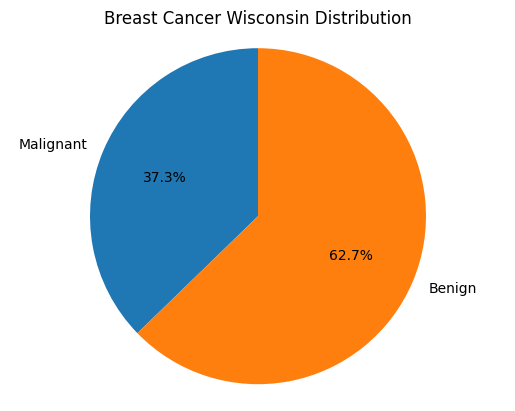

In [4]:
n_malignant = data.diagnosis.loc[data.diagnosis=="M"].count()
n_benign = data.diagnosis.loc[data.diagnosis=="B"].count()

plt.pie([n_malignant, n_benign], labels=["Malignant", "Benign"], autopct='%1.1f%%', startangle=90)
plt.title("Breast Cancer Wisconsin Distribution")
plt.axis('equal')
plt.show()

In [5]:
# Drop useless columns
data = data.drop(columns=["id", "Unnamed: 32"], axis=1)
# Reassign target values
data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0})
data

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [7]:
data.describe()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [8]:
data.corr()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,1.000000,0.730029,0.415185,0.742636,0.708984,0.358560,0.596534,0.696360,0.776614,0.330499,...,0.776454,0.456903,0.782914,0.733825,0.421465,0.590998,0.659610,0.793566,0.416294,0.323872
radius_mean,0.730029,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.415185,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.742636,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.708984,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,0.358560,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.596534,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.696360,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,0.776614,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry_mean,0.330499,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413


## Correlation Map

<Axes: >

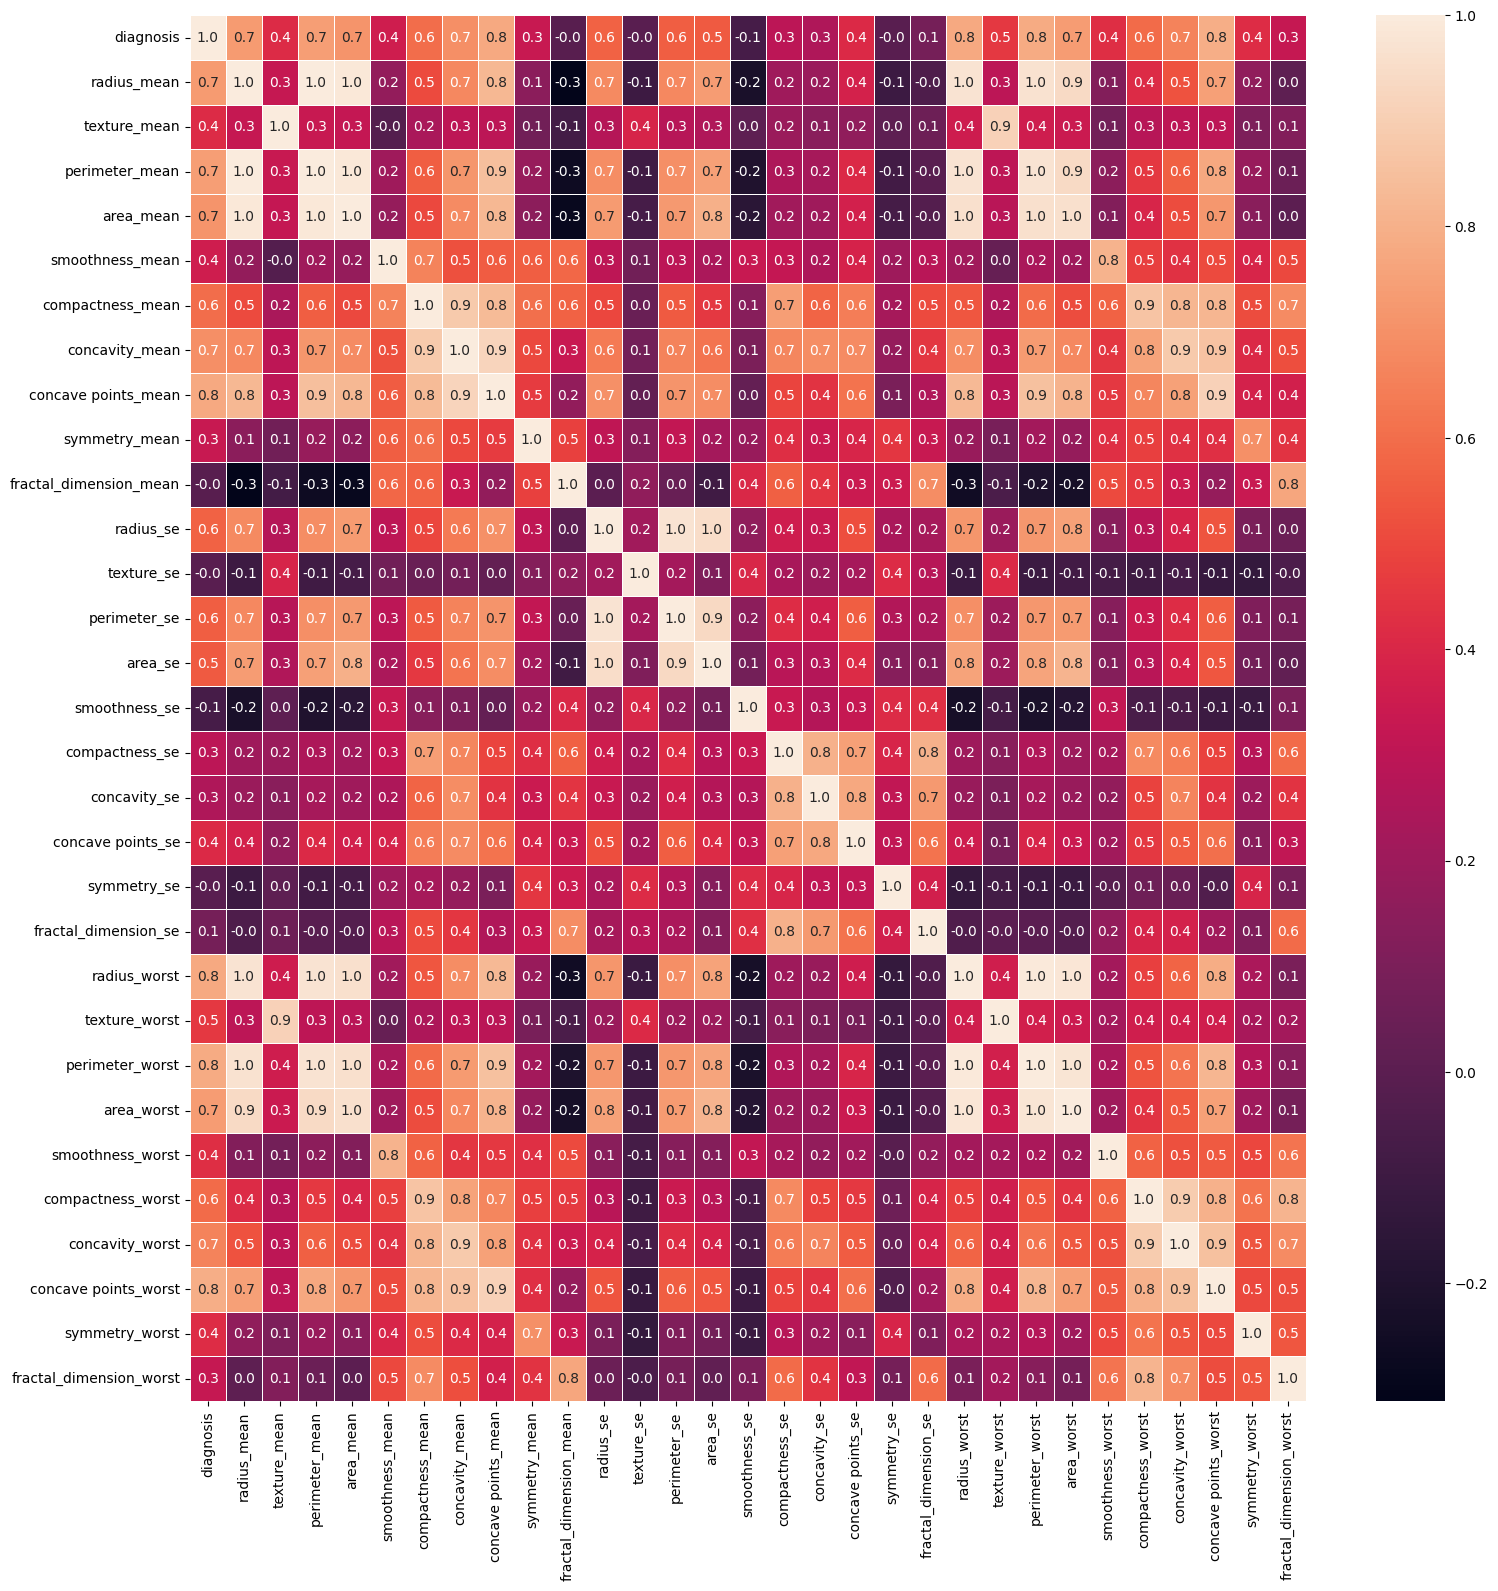

In [9]:
f,ax = plt.subplots(figsize=(18, 18))
sns.heatmap(data.corr(), annot=True, linewidths=.5, fmt= '.1f',ax=ax)

In [10]:
# Feature Selection

# drop_list = ['perimeter_mean','radius_mean','compactness_mean','concave points_mean','radius_se','perimeter_se','radius_worst','perimeter_worst','compactness_worst','concave points_worst','compactness_se','concave points_se','texture_worst','area_worst']
# selected_data = data.drop(drop_list, axis = 1 )
# selected_data.head()

## Splitting the dataset

In [11]:
train_data, test_data = train_test_split(data, test_size = 0.15, random_state=42)

In [12]:
# Splitting the features and the target label
X_train = train_data.iloc[:, 1:].values
y_train = train_data.iloc[:, 0].values

X_test = test_data.iloc[:, 1:].values
y_test = test_data.iloc[:, 0].values

## Normalization

In [13]:
X_train = (X_train - X_train.mean(axis=0)) / X_train.std(axis=0)
X_test = (X_test - X_test.mean(axis=0)) / X_test.std(axis=0)
# X_train = (X_train - np.min(X_train))/(np.max(X_train) - np.min(X_train))
# X_test = (X_test - np.min(X_test))/(np.max(X_test) - np.min(X_test))

In [14]:
print("X train: ",X_train.shape)
print("X test: ",X_test.shape)
print("y train: ",y_train.shape)
print("y test: ",y_test.shape)

X train:  (483, 30)
X test:  (86, 30)
y train:  (483,)
y test:  (86,)


# Logistic Regression Model

**Logistic regression** (also called logit regression) is commonly used to estimate the probability that an instance belongs to a particular class (e.g., what is the probability that this email is spam?). If the estimated probability is greater than a given threshold (typically 50%), then the model predicts that the instance belongs to that class (called the positive class, labeled “1”), and otherwise it predicts that it does not (i.e., it belongs to the negative class, labeled “0”). This makes it a binary classifier.

Just like a linear regression model, a logistic regression model computes a weighted sum of the input features (plus a bias term), but instead of outputting the result directly like the linear regression model does, it outputs the logistic of this result: $$f(x) = \sigma(wx + b)$$

Here, $\sigma$ is the sigmoid function: $$ \sigma(z) = {1 \over 1 + {e}^{-z}}$$

<div style="text-align: center;">
    <img width=750 src="https://cdn.britannica.com/64/264764-050-A2C174FD/graph-of-a-sigmoid-function.jpg">
</div>

The logistic—noted $\sigma$(·) — is a sigmoid function(i.e., S-shaped) that outputs a number between 0 and 1.

> The bad news is that there is no known closed-form equation to compute the value of $\theta$ that minimizes this cost function (there is no equivalent of the Normal equation). But the good news is that this cost function is convex, so gradient descent(or any other optimization algorithm) is guaranteed to find the global minimum.

***Logistic Regression Cost Function*** or ***Binary Crossentropy*** or ***Log Loss***: $$J(\theta) = -{1 \over m}\sum_{i=1}^m y^{(i)}\log(f(x^{(i)})) + (1 - y^{(i)})\log(1 - f(x^{(i)}))$$

In [15]:
class LogisticRegression:
    """
    Logistic Regression Model with Gradient Descent

    Logistic regression is a supervised machine learning algorithm used for modeling the relationship
    between a dependent variable (target) and one or more independent variables (features) by
    fitting the sigmoid function to the observed data.
    
    Parameters:
        learning_rate(float): The learning rate used in gradient descent
        convergence_tol (float, optional): The tolerance for convergence (stopping criterion). Defaults to 1e-6.

    Attributes:
        W (numpy.ndarray): Coefficients (weights) for the linear regression model.
        b (float): Intercept (bias) for the linear regression model.

    Methods:
        initialize_parameters(n_features): Initialize model parameters.
        forward(X): Compute the forward pass of the logistic regression model.
        compute_cost(predictions): Compute the binary cross entropy.
        backward(predictions): Compute gradients for model parameters.
        fit(X, y, iterations, plot_cost=True): Fit the linear regression model to training data.
        predict(X): Predict target values for new input data.
        save_model(filename=None): Save the trained model to a file using pickle.
        load_model(filename): Load a trained model from a file using pickle.
        
    """

    def __init__(self, learning_rate):
        self.learning_rate = learning_rate
        self.W = None
        self.b = None

    def initialize_parameters(self, n_features):
        """
        Initialize Model parameters
        Parameters:
            n_features (int):  The number of features in the input data
        """

        self.W = np.random.rand(n_features) * 0.01
        self.b = 0.0

    def sigmoid(self, z):
        """
        Implements the sigmoid function.
        Parameters:
            z (float): The input to the sigmoid function(logit)
        Returns:
            Computes the logisctics of the logits.
        """
        return 1 / (1 + np.exp(-z))

    def forward(self, X):
        """
        Compute the forward pass of the linear regression model

        Parameters:
            X (numpy.ndarray): Input data of shape (m, n_features)

        Returns:
            numpy.ndarray: Predictions of shape (m,).
        """
        z = np.dot(self.W.T, X.T) + self.b
        return self.sigmoid(z)

    def compute_cost(self, y_pred):
        """
        Compute the binary crossentropy.

        Parameters:
            predictions (numpy.ndarray): Predictions of shape (m,).

        Returns:
            float: Mean squared error cost.
        """
        m = len(y_pred)
        y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
        cost = (1 / m) * np.sum(-self.y * np.log(y_pred) - (1 - self.y)*np.log(1 - y_pred))
        return cost

    def output(self, probabilities, threshold=0.5):
        return (probabilities > threshold).astype(int)

    def compute_accuracy(self, probabilities):
        y_pred = self.output(probabilities)
        return np.mean(y_pred == self.y)

    def backward(self, probabilities):
        """
        Compute gradients for model parameters

        Parameters:
            predictions (numpy.ndarray): Predictions of shape (m,)

        Updates:
            numpy.ndarray: Gradient of W
            float: Gradient of b
        """
        m = len(probabilities)
        self.dW = np.dot(self.X.T, probabilities - self.y) / m
        self.db = np.sum(probabilities - self.y) / m

    def fit(self, X, y, iterations, plot_cost=True):
        """
        Fit the logistic regression model to the training data.

        Parameters:
            X (numpy.ndarray): Training input data of shape (m, n_features).
            y (numpy.ndarray): Training labels of shape (m,).
            iterations (int): The number of iterations for gradient descent.
            plot_cost (bool, optional): Whether to plot the cost during training. Defaults to True.

        Raises:
            AssertionError: If input data and labels are not NumPy arrays or have mismatched shapes.

        Plots:
            Line chart showing cost vs. iteration (if plot_cost is True).
        """
        assert isinstance(X, np.ndarray), "X must be a NumPy array"
        assert isinstance(y, np.ndarray), "y must be a NumPy array"
        assert X.shape[0] == y.shape[0], "X and y must have the same number of samples"
        assert iterations > 0, "Iterations must be greater than 0"

        self.X = X
        self.y = y
        self.initialize_parameters(X.shape[1])
        costs = []

        for i in range(iterations+1):
            # Forward pass
            probabilities = self.forward(X)
            cost = self.compute_cost(probabilities)
            accuracy = self.compute_accuracy(probabilities)
            # Backward pass
            self.backward(probabilities)
            self.W -= self.learning_rate * self.dW
            self.b -= self.learning_rate * self.db
            costs.append(cost)

            if i % 10 == 0:
                print(f'Iteration: {i}, Cost: {cost}, Accuracy: {accuracy}')
            # if i > 0 and abs(costs[-1] - costs[-2]) < self.convergence_tol:
            #     print(f'Converged after {i} iterations')
            #     n_iterations = i
            #     break
                
        plt.plot(np.arange(iterations+1), costs)
        plt.title("Cost vs Iterations", fontsize=14)
        plt.xlabel("Iterations", fontsize=12)
        plt.ylabel("Cost", fontsize=12)
        plt.grid(True)
        plt.show()

    def predict(self, X):
        """
        Predict target values for new input data.

        Parameters:
            X (numpy.ndarray): Input data of shape (m, n_features).

        Returns:
            numpy.ndarray: Predicted target values of shape (m,).
        """
        probabilities = self.forward(X)
        return self.output(probabilities), probabilities

    def save_model(self, filename=None):
        model_data = {
            'learning_rate': self.learning_rate,
            'convergence_tol': self.convergence_tol,
            'W': self.W,
            'b': self.b
        }

        with open(filename, 'wb') as file:
            pickle.dump(model_data, file)

    @classmethod
    def load_model(cls, filename):
        with open(filename, 'rb') as file:
            model_data = pickle.load(file)

        # Create a new instance of the class and initialize it with the loaded parameters
        loaded_model = cls(model_data['learning_rate'], model_data['convergence_tol'])
        loaded_model.W = model_data['W']
        loaded_model.b = model_data['b']

        return loaded_model

Iteration: 0, Cost: 0.6647531587005988, Accuracy: 0.8799171842650103
Iteration: 10, Cost: 0.24509980227981776, Accuracy: 0.9544513457556936
Iteration: 20, Cost: 0.1866358516921617, Accuracy: 0.9627329192546584
Iteration: 30, Cost: 0.15960411818459583, Accuracy: 0.968944099378882
Iteration: 40, Cost: 0.14341219424645113, Accuracy: 0.968944099378882
Iteration: 50, Cost: 0.1323960137440336, Accuracy: 0.9710144927536232
Iteration: 60, Cost: 0.12429856959375304, Accuracy: 0.9710144927536232
Iteration: 70, Cost: 0.1180302452760921, Accuracy: 0.9730848861283644
Iteration: 80, Cost: 0.11299517847598528, Accuracy: 0.979296066252588
Iteration: 90, Cost: 0.10883734237304106, Accuracy: 0.979296066252588
Iteration: 100, Cost: 0.10532945218339572, Accuracy: 0.979296066252588


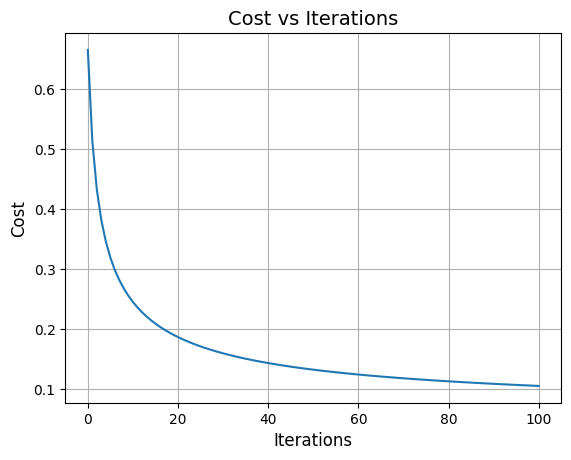

In [16]:
model = LogisticRegression(0.1)
model.fit(X_train, y_train, 100)

# Evaluation

In [17]:
class ClassificationMetrics:
    @staticmethod
    def binary_crossentropy(y_true, y_pred):
        m = y_true.shape[0]
        y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
        binary_crossentropy = (1 / m) * np.sum(-y_true * np.log(y_pred) - (1 - y_true) * np.log(1 - y_pred))
        return binary_crossentropy

    @staticmethod
    def accuracy(y_true, y_pred):
        return np.mean(y_pred == y_true)

    @staticmethod
    def precision(y_true, y_pred):
        TP = sum(1 for yt, yp in zip(y_true, y_pred) if yt == 1 and yp == 1)
        FP = sum(1 for yt, yp in zip(y_true, y_pred) if yt == 0 and yp == 1)
        precision = TP / (TP + FP)
        return precision

    def recall(y_true, y_pred):
        TP = sum(1 for yt, yp in zip(y_true, y_pred) if yt == 1 and yp == 1)
        FN = sum(1 for yt, yp in zip(y_true, y_pred) if yt == 1 and yp == 0)
        recall = TP / (TP + FN)
        return recall

    def F1_score(y_true, y_pred):
        TP = sum(1 for yt, yp in zip(y_true, y_pred) if yt == 1 and yp == 1)
        FP = sum(1 for yt, yp in zip(y_true, y_pred) if yt == 0 and yp == 1)
        P = TP / (TP + FP)
        FN = sum(1 for yt, yp in zip(y_true, y_pred) if yt == 1 and yp == 0)
        R = TP / (TP + FN)
        f1_score = 2*P*R / (P + R)
        return f1_score

In [18]:
y_test_pred, y_proba = model.predict(X_test)
log_loss = ClassificationMetrics.binary_crossentropy(y_test, y_test_pred)
precision = ClassificationMetrics.precision(y_test, y_test_pred)
recall = ClassificationMetrics.recall(y_test, y_test_pred)
f1_score = ClassificationMetrics.F1_score(y_test, y_test_pred)
accuracy = ClassificationMetrics.accuracy(y_test, y_test_pred)

results = pd.DataFrame({
    "Logistic Regression": [accuracy, log_loss, precision, recall, f1_score]
    }, index=["Accuracy", "Log Loss", "Precision", "Recall", "F1 Score"]
)
results

,Logistic Regression
Accuracy,0.988372
Log Loss,0.401614
Precision,1.000000
Recall,0.968750
F1 Score,0.984127


## ROC Curve

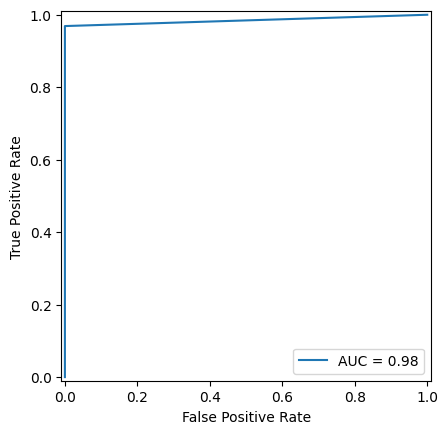

In [19]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred)
roc_auc = auc(fpr, tpr)
roccurve = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
roccurve.plot()
plt.show()

## Precision Recall Curve

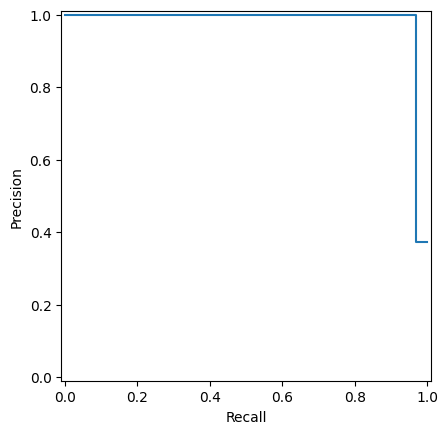

In [20]:
p, r , _= precision_recall_curve(y_test, y_test_pred)

prcurve = PrecisionRecallDisplay(p, r)
prcurve.plot()
plt.show()

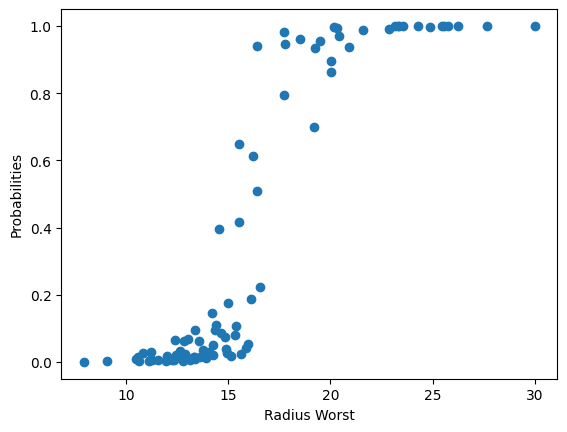

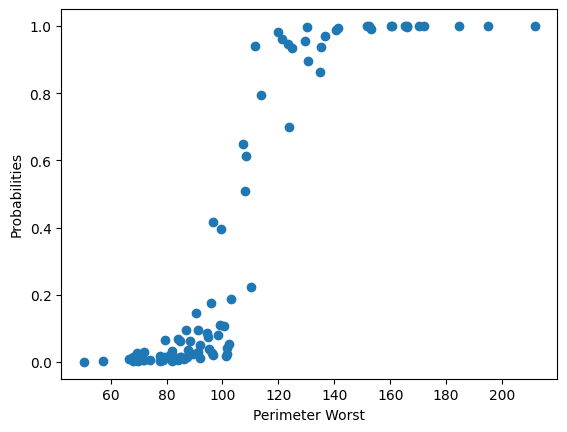

In [21]:
plt.scatter(test_data["radius_worst"], y_proba)
plt.xlabel("Radius Worst")
plt.ylabel("Probabilities")
plt.show()

plt.scatter(test_data["perimeter_worst"], y_proba)
plt.xlabel("Perimeter Worst")
plt.ylabel("Probabilities")
plt.show()

Now it seems to fit the sigmoid function!

# Comparing to Scikit-Learn Model

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

clf = LogisticRegression()
clf.fit(X_train, y_train)

clf_pred = clf.predict(X_test)
clf_acc = accuracy_score(y_test, clf_pred)
clf_report = classification_report(y_test, clf_pred)

print(f"Accuracy: {clf_acc}\n")
print(f"Classification Report:\n {clf_report}")

Accuracy: 0.9767441860465116

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        54
           1       1.00      0.94      0.97        32

    accuracy                           0.98        86
   macro avg       0.98      0.97      0.97        86
weighted avg       0.98      0.98      0.98        86



> Achieved comparable performance to scikit-learn model ✔

### Thank You!

<div style="background-color:#D0FF1D; padding:20px; border-radius: 8px; color: #000; text-decoration: none;">
    <div style="font-weight: 700; font-size: 38px; text-align: center;">Machine Learning Algorithms From Scratch</div>
    <a href="https://www.kaggle.com/code/aakcodebreaker/linear-regression-from-scratch" style="color:#000; text-decoration:underline; font-size: 26px">1. Linear Regression</a>
    <br>
    <a href="https://www.kaggle.com/code/aakcodebreaker/logistic-regression-from-scratch" style="color:#000; text-decoration: underline; font-size: 26px;">2. Logistic Regression</a>
    <br>
    <a href="https://www.kaggle.com/code/aakcodebreaker/svm-classification-from-scratch" style="color:#000; text-decoration: underline; font-size: 26px;">3. SVM Classification</a>
</div>